# Replicant — Convergence Benchmark Analysis

Loads `results.csv` from the repo root and produces thesis-ready figures in `figures/`.

**Generate results first** (release build — debug timings carry tens of ms of overhead that swamps real signal):
```sh
cargo run --release --bin orchestrator -- --trials 10 --output csv \
  scenarios/*.toml \
  2>/dev/null > results.csv
```

> **If regenerating after a code change:** the CSV is cached as `results.parquet` for
> faster reruns. The cache is refreshed automatically when `results.csv` is newer than
> `results.parquet`. To force a rebuild, delete `results.parquet` manually.

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 150

REPO = Path("..").resolve()  # absolute repo root; works regardless of launch CWD
CSV     = REPO / "results.csv"
PARQUET = REPO / "results.parquet"
FIGS    = REPO / "analysis" / "figures"
FIGS.mkdir(exist_ok=True)

## Load data

On first run the CSV is parsed and cached as Parquet (preserves dtypes, loads faster on reruns).

In [2]:
csv_mtime = CSV.stat().st_mtime if CSV.exists() else 0
parquet_fresh = PARQUET.exists() and PARQUET.stat().st_mtime >= csv_mtime

if parquet_fresh:
    df = pd.read_parquet(PARQUET)
else:
    df = pd.read_csv(CSV)
    df.to_parquet(PARQUET)

trials  = df[df.row_type == "trial"].copy()
summary = df[df.row_type == "summary"].copy()
# In summary rows the `trial` column holds the trial count, not a trial number.
summary = summary.rename(columns={"trial": "n_trials"})

print(f"{len(trials)} trial records, {trials.scenario.nunique()} scenarios, "
      f"{trials.groupby('scenario').size().iloc[0]} trials each")
summary[["scenario", "n_trials", "node_count", "op_count", "mean_ms", "p50_ms", "p95_ms"]]

190 trial records, 19 scenarios, 10 trials each


,scenario,n_trials,node_count,op_count,mean_ms,p50_ms,p95_ms
10,full-mesh-n2,10,2,2,0.861,0.751,1.533
21,full-mesh-n3,10,3,6,1.995,1.988,2.463
32,full-mesh-n5,10,5,10,4.729,4.572,6.055
43,full-mesh-n10,10,10,20,42.390,41.633,51.565
54,ring-n5,10,5,10,2.623,2.643,2.689
65,ring-n10,10,10,20,7.931,6.894,9.818
76,line-n5,10,5,10,4.959,4.922,5.075
87,line-n10,10,10,20,9.397,9.385,9.679
98,star-n5,10,5,10,4.780,5.235,5.646
109,star-n10,10,10,20,21.695,21.939,26.239


## Full-mesh: convergence vs node count

Measures time from last write to all-nodes fingerprint agreement.
Shaded band shows p50–p95 range across trials.

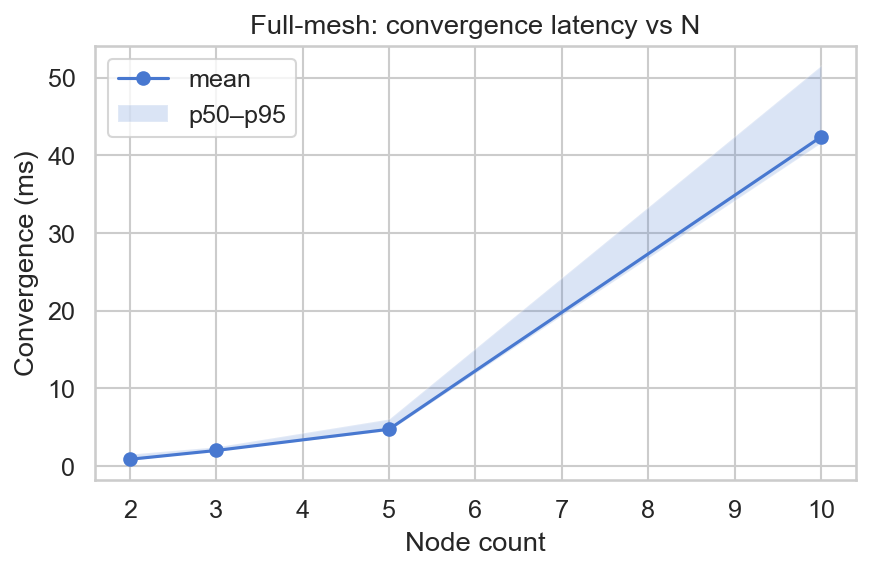

In [3]:
mesh = summary[summary.scenario.str.startswith("full-mesh")].sort_values("node_count")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(mesh.node_count, mesh.mean_ms, "o-", label="mean")
ax.fill_between(mesh.node_count, mesh.p50_ms, mesh.p95_ms, alpha=0.2, label="p50–p95")
ax.set_xlabel("Node count")
ax.set_ylabel("Convergence (ms)")
ax.set_title("Full-mesh: convergence latency vs N")
ax.legend()
fig.tight_layout()
fig.savefig(FIGS / "full_mesh_scaling.pdf")
plt.show()

## Partition-heal: convergence vs partition depth

Measures time from heal trigger (cross-group edges added) to global convergence.
`ConnectPeer` blocks until the Automerge sync handshake is open (via an internal
readiness signal), so these numbers reflect actual CRDT merge cost rather than
any fixed settle delay.

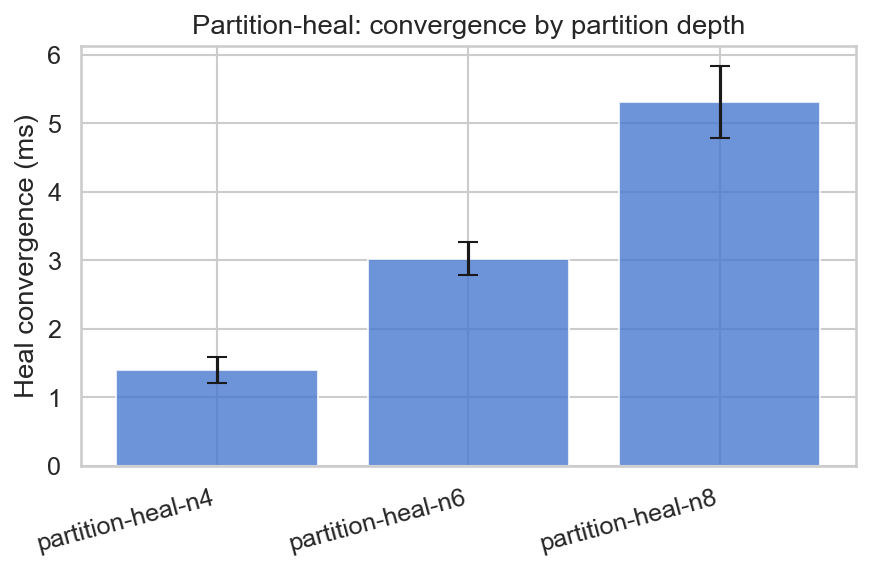

In [4]:
heal = summary[summary.scenario.str.startswith("partition")].sort_values("node_count")

fig, ax = plt.subplots(figsize=(6, 4))
x = range(len(heal))
yerr = (heal.p95_ms - heal.mean_ms).clip(lower=0)
ax.bar(x, heal.mean_ms, yerr=yerr, capsize=5, alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(heal.scenario, rotation=15, ha="right")
ax.set_ylabel("Heal convergence (ms)")
ax.set_title("Partition-heal: convergence by partition depth")
fig.tight_layout()
fig.savefig(FIGS / "partition_heal.pdf")
plt.show()

## Convergence vs N — by topology kind

Each topology family scales differently. Restricted to `round_robin` writes so the topology comparison isn't confounded by write pattern; `concentrated` variants appear in the diameter plot below. Error bars span p50–p95.

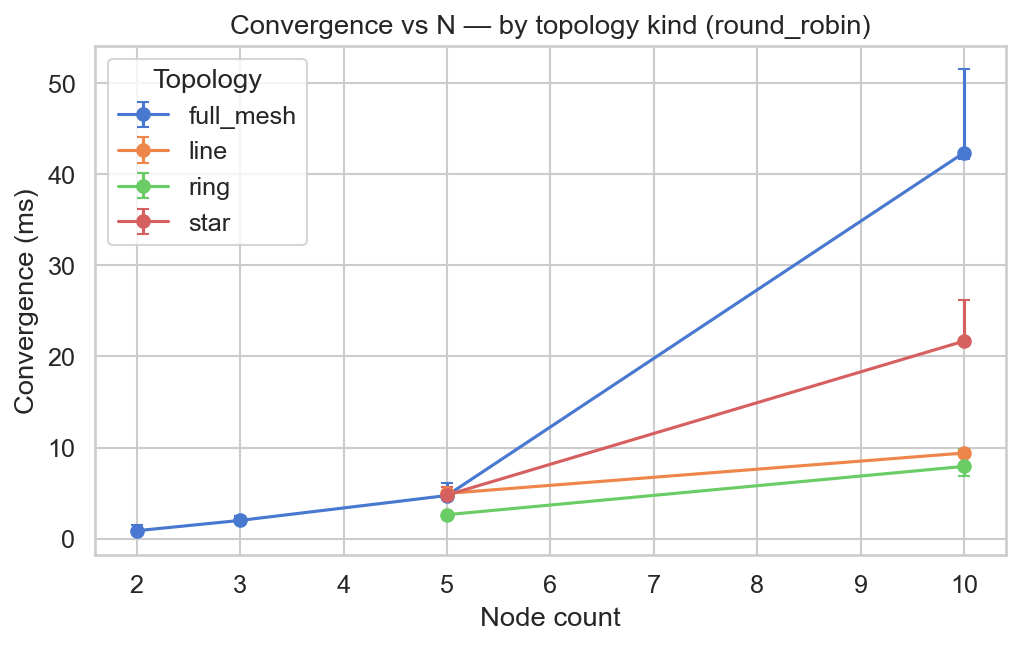

In [5]:
topo = summary[
    (~summary.scenario.str.endswith("-concentrated"))
    & (summary.topology_kind.isin(["full_mesh", "ring", "line", "star"]))
].sort_values(["topology_kind", "node_count"])

fig, ax = plt.subplots(figsize=(7, 4.5))
for kind, group in topo.groupby("topology_kind"):
    yerr_low = (group.mean_ms - group.p50_ms).clip(lower=0)
    yerr_high = (group.p95_ms - group.mean_ms).clip(lower=0)
    ax.errorbar(
        group.node_count,
        group.mean_ms,
        yerr=[yerr_low, yerr_high],
        marker="o",
        capsize=3,
        label=kind,
    )
ax.set_xlabel("Node count")
ax.set_ylabel("Convergence (ms)")
ax.set_title("Convergence vs N — by topology kind (round_robin)")
ax.legend(title="Topology")
fig.tight_layout()
fig.savefig(FIGS / "convergence_vs_n_by_topology.pdf")
plt.show()

## Convergence vs diameter — the structural correlate

Diameter is the longest shortest-path in the topology — the minimum number of hops any state must traverse to fully propagate. Conventional wisdom predicts `convergence_ms ~ diameter`, but Phase A's relay-on-receive amplifies with **edge count** and **max degree** too.

Below scatters every non-partition scenario by `(diameter, mean_ms)`, coloured by topology kind and shaped by write pattern. **Diameter alone does not predict convergence**: full-mesh (diameter = 1) ranges from <1 ms (n = 2) to >40 ms (n = 10) because edge count grows with N²; line-n10 (diameter 9) converges faster than full-mesh-n10 (diameter 1) because the line has only 9 edges vs 45.

This is the thesis's negative result: diameter is necessary (no traversal can be shorter) but not sufficient for predicting CRDT convergence under a relay-flooded sync layer.

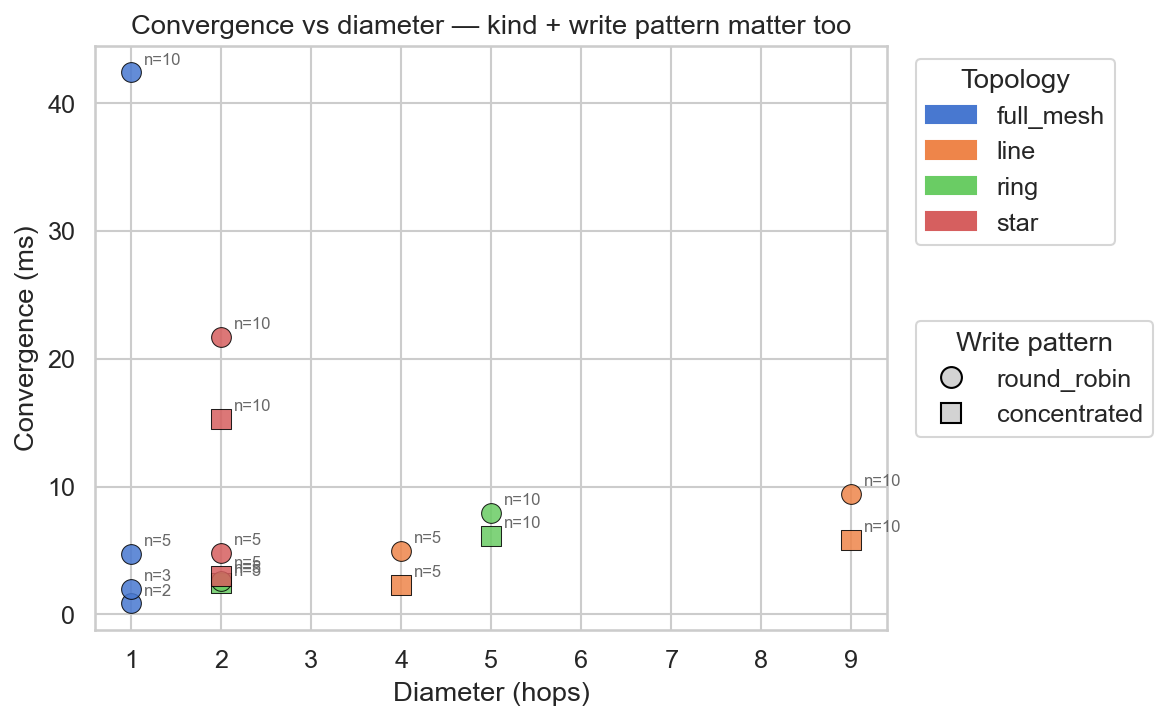

In [6]:
import matplotlib.patches as mpatches

diam_df = summary[summary.topology_kind != "partition_heal"].copy()
diam_df["write_pattern"] = diam_df.scenario.apply(
    lambda s: "concentrated" if s.endswith("-concentrated") else "round_robin"
)

kinds = sorted(diam_df.topology_kind.unique())
palette = dict(zip(kinds, sns.color_palette("muted", n_colors=len(kinds))))
markers = {"round_robin": "o", "concentrated": "s"}

fig, ax = plt.subplots(figsize=(8, 5))
for (kind, pat), group in diam_df.groupby(["topology_kind", "write_pattern"]):
    ax.scatter(
        group.diameter,
        group.mean_ms,
        marker=markers[pat],
        s=90,
        color=palette[kind],
        edgecolor="black",
        linewidth=0.5,
        alpha=0.85,
    )

for _, row in diam_df.iterrows():
    ax.annotate(
        f"n={row.node_count}",
        (row.diameter, row.mean_ms),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=8,
        color="dimgray",
    )

color_legend = [mpatches.Patch(color=palette[k], label=k) for k in kinds]
shape_legend = [
    plt.Line2D([0], [0], marker=markers[pat], color="black", linestyle="",
               markerfacecolor="lightgray", markersize=10, label=pat)
    for pat in markers
]
first_legend = ax.legend(handles=color_legend, title="Topology",
                          loc="upper left", bbox_to_anchor=(1.02, 1))
ax.add_artist(first_legend)
ax.legend(handles=shape_legend, title="Write pattern",
          loc="upper left", bbox_to_anchor=(1.02, 0.55))

ax.set_xlabel("Diameter (hops)")
ax.set_ylabel("Convergence (ms)")
ax.set_title("Convergence vs diameter — kind + write pattern matter too")
fig.tight_layout()
fig.savefig(FIGS / "convergence_vs_diameter.pdf", bbox_inches="tight")
plt.show()

## Raw distributions (box plots)

Shows the full trial distribution rather than summary statistics.
More honest for small N — outliers are visible.

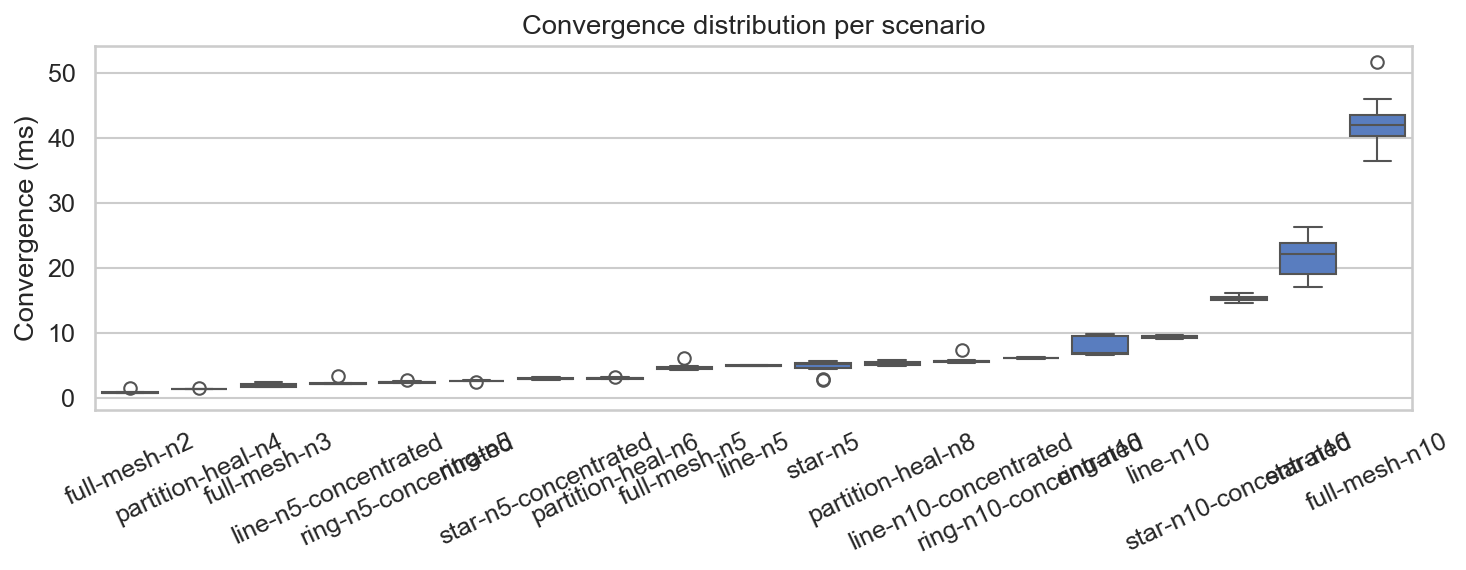

In [7]:
order = (
    trials.groupby("scenario")["convergence_ms"]
    .median()
    .sort_values()
    .index
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=trials, x="scenario", y="convergence_ms", order=order, ax=ax)
ax.tick_params(axis="x", rotation=25)
ax.set_xlabel(None)
ax.set_ylabel("Convergence (ms)")
ax.set_title("Convergence distribution per scenario")
fig.tight_layout()
fig.savefig(FIGS / "boxplot.pdf")
plt.show()

## Summary table

Formatted for copy-paste into the thesis evaluation section.

In [8]:
table = summary[["scenario", "node_count", "n_trials", "mean_ms", "p50_ms", "p95_ms"]].copy()
table.columns = ["Scenario", "Nodes", "Trials", "Mean (ms)", "p50 (ms)", "p95 (ms)"]
table = table.set_index("Scenario")
table.round(1)

,Nodes,Trials,Mean (ms),p50 (ms),p95 (ms)
Scenario,,,,,
full-mesh-n2,2,10,0.9,0.8,1.5
full-mesh-n3,3,10,2.0,2.0,2.5
full-mesh-n5,5,10,4.7,4.6,6.1
full-mesh-n10,10,10,42.4,41.6,51.6
ring-n5,5,10,2.6,2.6,2.7
ring-n10,10,10,7.9,6.9,9.8
line-n5,5,10,5.0,4.9,5.1
line-n10,10,10,9.4,9.4,9.7
star-n5,5,10,4.8,5.2,5.6


## Measurement stability

Standard deviation and coefficient of variation (CV = σ/μ) across trials.
CV < 10% is generally stable; CV > 30% suggests the measurement is noisy
and more trials or a quieter environment are needed.

In [9]:
stability = (
    trials.groupby("scenario")["convergence_ms"]
    .agg(mean="mean", std="std", n="count")
    .assign(cv_pct=lambda df: (df["std"] / df["mean"] * 100).round(1))
    .round({"mean": 2, "std": 2})
    .sort_values("cv_pct", ascending=False)
)
stability.columns = ["Mean (ms)", "Std (ms)", "N trials", "CV (%)"]

# Highlight rows where CV exceeds 20% — worth investigating
def highlight_cv(row):
    return ["background-color: #fdd" if row["CV (%)"] > 20 else "" for _ in row]

stability.style.apply(highlight_cv, axis=1)

,Mean (ms),Std (ms),N trials,CV (%)
scenario,,,,
full-mesh-n2,0.860000,0.250000,10,29.400000
star-n5,4.780000,1.070000,10,22.400000
ring-n10,7.930000,1.480000,10,18.600000
line-n5-concentrated,2.290000,0.360000,10,15.700000
full-mesh-n3,1.990000,0.310000,10,15.500000
star-n10,21.690000,3.060000,10,14.100000
full-mesh-n5,4.730000,0.510000,10,10.700000
line-n10-concentrated,5.800000,0.590000,10,10.100000
full-mesh-n10,42.390000,4.190000,10,9.900000


## OTel Protocol Metrics

Loaded from per-scenario `metrics-<scenario>.json` files written by the orchestrator when `--metrics-file` is passed.

OTel counters accumulate across every scenario in a single run, so **run one scenario at a time** to get per-scenario metrics. The loop below covers every TOML in `scenarios/`:

```sh
for s in $(ls scenarios/*.toml | xargs -n1 basename -s .toml); do
  cargo run --release --bin orchestrator -- --trials 10 \
    --metrics-file "metrics-${s}.json" \
    "scenarios/${s}.toml" \
    > /dev/null 2>&1
done
```

The `Sync traffic per write op` cell below reads every `metrics-<scenario>.json` and produces a cross-topology comparison.

Point `METRICS` below at any single file (e.g. `REPO / "metrics-full-mesh-n5.json"`) to inspect one scenario's per-node breakdown.

> **Multi-scenario (cumulative) alternative** — useful only as a sanity check that overall protocol traffic looks reasonable; values cannot be attributed to individual scenarios:
> ```sh
> cargo run --release --bin orchestrator -- --trials 10 --output csv \
>   --metrics-file metrics-all.json \
>   scenarios/*.toml \
>   2>/dev/null > results.csv
> ```

In [10]:
import json

# Point this at a single-scenario metrics file for per-scenario analysis,
# e.g. REPO / "metrics-full-mesh-n5.json".
# Use REPO / "metrics-all.json" for the cumulative multi-scenario view.
METRICS = REPO / "metrics.json"


def load_metrics(path: Path) -> dict[str, pd.DataFrame] | None:
    """Parse a metrics JSON Lines file into a dict of DataFrames keyed by metric name.

    Each line in the file is a JSON object ``{"metrics": [...]}``.
    Data points from multiple flushes are concatenated per metric name.
    Returns None if the file does not exist.
    """
    if not path.exists():
        print(f"[metrics] {path} not found — run the per-scenario loop above first.")
        return None

    rows: list[dict] = []
    with open(path) as fh:
        for line in fh:
            line = line.strip()
            if line:
                rows.append(json.loads(line))

    by_name: dict[str, list[dict]] = {}
    for record in rows:
        for m in record.get("metrics", []):
            by_name.setdefault(m["name"], []).extend(m["data_points"])

    return {name: pd.DataFrame(points) for name, points in by_name.items()}


metrics = load_metrics(METRICS)
if metrics:
    print("Loaded metrics:", list(metrics.keys()))
    for name, df_m in metrics.items():
        print(f"  {name}: {len(df_m)} data points, columns={list(df_m.columns)}")

Loaded metrics: ['replicant.op.duration', 'replicant.sync.messages.tx', 'replicant.sync.messages.rx', 'replicant.doc.size_bytes']
  replicant.op.duration: 10 data points, columns=['actor', 'count', 'max', 'min', 'op', 'sum']
  replicant.sync.messages.tx: 90 data points, columns=['actor', 'peer', 'value']
  replicant.sync.messages.rx: 90 data points, columns=['actor', 'peer', 'value']
  replicant.doc.size_bytes: 10 data points, columns=['actor', 'value']


### Sync message traffic

Total Automerge sync messages sent and received per node.
Shows how much protocol chatter each node generates — useful for arguing O(N²) scaling of the gossip layer.


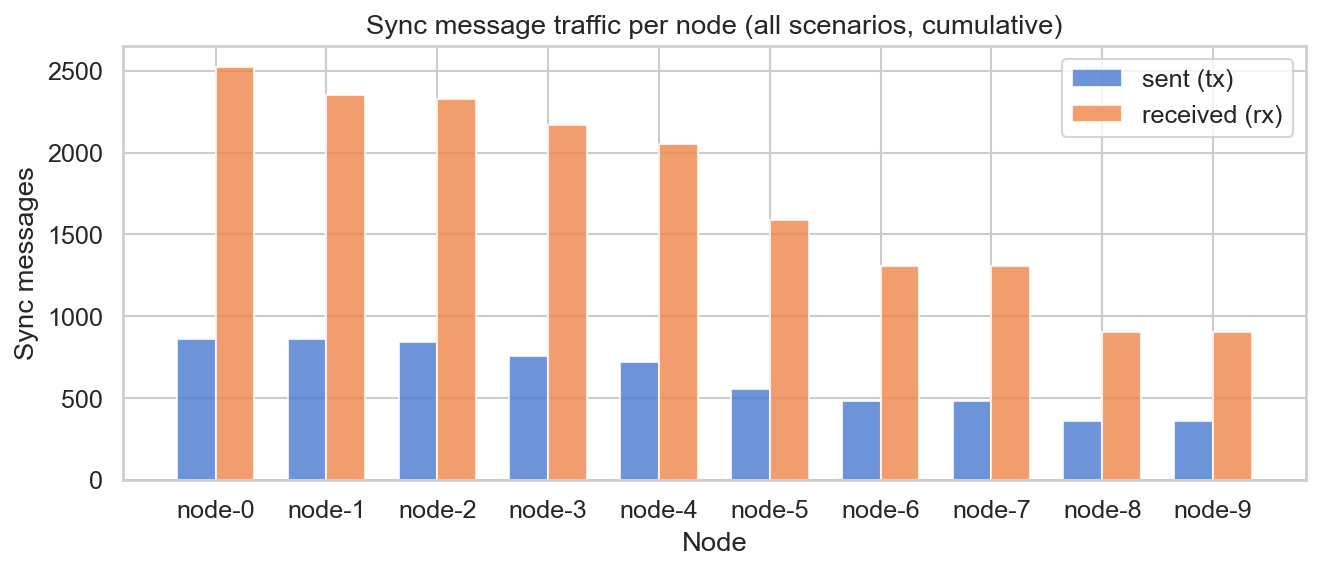

         tx    rx  total
actor                   
node-0  859  2526   3385
node-1  858  2353   3211
node-2  840  2330   3170
node-3  759  2171   2930
node-4  720  2050   2770
node-5  558  1586   2144
node-6  480  1307   1787
node-7  480  1305   1785
node-8  360   906   1266
node-9  360   904   1264


In [11]:
if metrics:
    tx = metrics["replicant.sync.messages.tx"].groupby("actor")["value"].sum().rename("tx")
    rx = metrics["replicant.sync.messages.rx"].groupby("actor")["value"].sum().rename("rx")
    traffic = pd.concat([tx, rx], axis=1).fillna(0).astype(int)
    # Sort nodes naturally (node-0, node-1, …)
    traffic = traffic.loc[sorted(traffic.index, key=lambda s: int(s.split("-")[1]))]

    fig, ax = plt.subplots(figsize=(max(4, len(traffic) * 0.9), 4))
    x = range(len(traffic))
    width = 0.35
    ax.bar([i - width / 2 for i in x], traffic["tx"], width, label="sent (tx)", alpha=0.8)
    ax.bar([i + width / 2 for i in x], traffic["rx"], width, label="received (rx)", alpha=0.8)
    ax.set_xticks(list(x))
    ax.set_xticklabels(traffic.index)
    ax.set_xlabel("Node")
    ax.set_ylabel("Sync messages")
    ax.set_title("Sync message traffic per node (all scenarios, cumulative)")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGS / "sync_traffic.pdf")
    plt.show()
    print(traffic.assign(total=traffic.tx + traffic.rx).sort_values("total", ascending=False))


## Sync traffic per write op — by scenario

Loads every per-scenario `metrics-<scenario>.json` file (one per scenario, generated by the loop in the markdown above) and sums `tx + rx` across all nodes. Dividing by `trials × op_count` yields **sync messages per write op**, comparable across scenarios with different N and op_count.

This quantifies the **amplification cost** of Phase A's relay-on-receive fix: more edges (higher topology connectivity) → more redundant fan-out per write. It explains why full-mesh-n10 (45 edges) converges slower than line-n10 (9 edges) despite the shorter diameter — the line has 10× fewer message paths to flood.

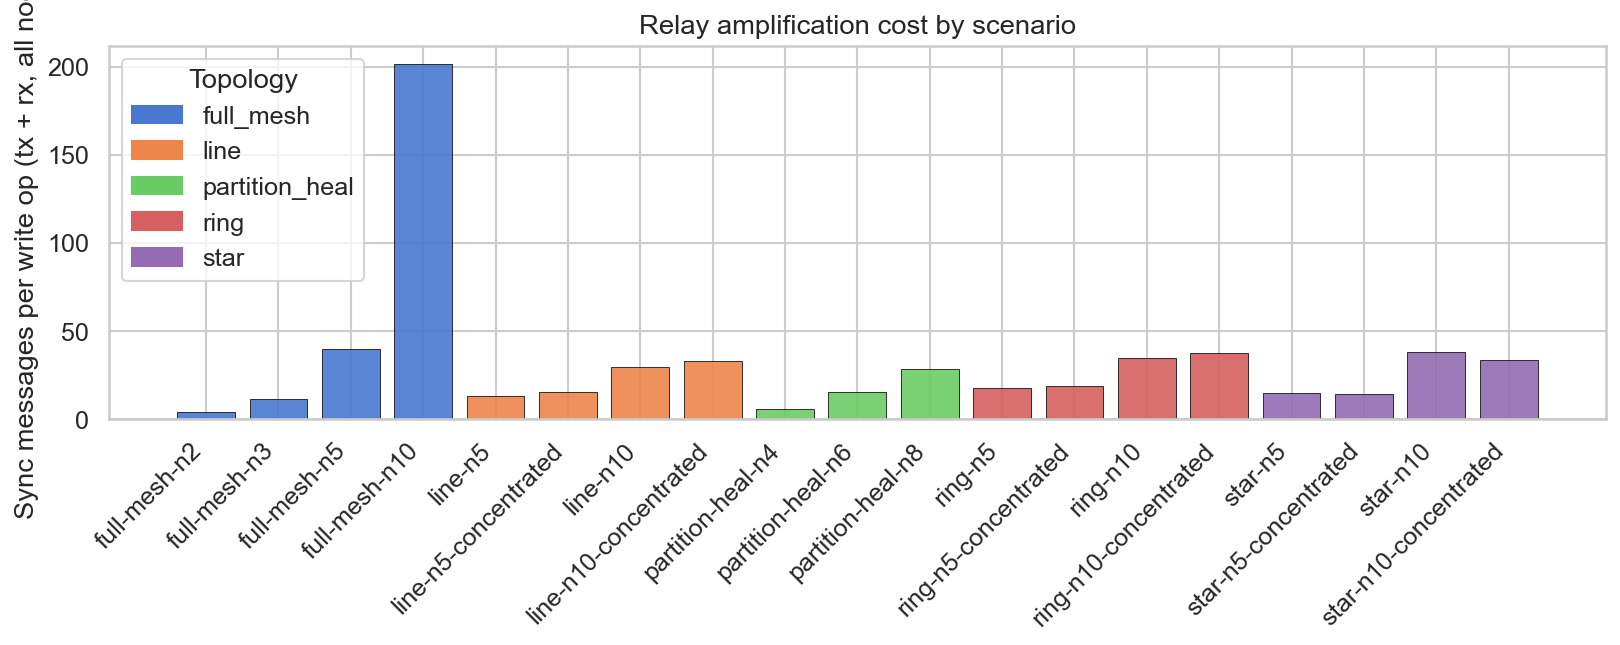

,scenario,topology_kind,node_count,edge_count,diameter,msgs_per_op
0,full-mesh-n2,full_mesh,2,1,1,3.95
1,full-mesh-n3,full_mesh,3,3,1,11.20
2,full-mesh-n5,full_mesh,5,10,1,39.87
3,full-mesh-n10,full_mesh,10,45,1,201.68
4,line-n5,line,5,4,4,13.31
5,line-n5-concentrated,line,5,4,4,15.18
6,line-n10,line,10,9,9,29.76
7,line-n10-concentrated,line,10,9,9,33.11
8,partition-heal-n4,partition_heal,4,6,1,5.91
9,partition-heal-n6,partition_heal,6,15,1,15.11


In [12]:
import matplotlib.patches as mpatches

sync_rows = []
for scen in summary.scenario.unique():
    mpath = REPO / f"metrics-{scen}.json"
    m = load_metrics(mpath)
    if m is None or "replicant.sync.messages.tx" not in m:
        continue
    tx_total = int(m["replicant.sync.messages.tx"]["value"].sum())
    rx_total = int(m["replicant.sync.messages.rx"]["value"].sum())
    s_row = summary[summary.scenario == scen].iloc[0]
    sync_rows.append({
        "scenario": scen,
        "topology_kind": s_row.topology_kind,
        "node_count": int(s_row.node_count),
        "edge_count": int(s_row.edge_count),
        "diameter": int(s_row.diameter),
        "msgs_per_op": (tx_total + rx_total) / (s_row.n_trials * s_row.op_count),
    })
sync_df = pd.DataFrame(sync_rows).sort_values(["topology_kind", "node_count"]).reset_index(drop=True)

kinds = sorted(sync_df.topology_kind.unique())
palette = dict(zip(kinds, sns.color_palette("muted", n_colors=len(kinds))))
bar_colors = [palette[k] for k in sync_df.topology_kind]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(sync_df.scenario, sync_df.msgs_per_op,
       color=bar_colors, edgecolor="black", linewidth=0.4, alpha=0.9)
ax.tick_params(axis="x", rotation=45)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
ax.set_xlabel(None)
ax.set_ylabel("Sync messages per write op (tx + rx, all nodes)")
ax.set_title("Relay amplification cost by scenario")
legend_handles = [mpatches.Patch(color=palette[k], label=k) for k in kinds]
ax.legend(handles=legend_handles, title="Topology", loc="upper left")
fig.tight_layout()
fig.savefig(FIGS / "sync_vs_topology.pdf")
plt.show()
sync_df.round(2)

### Op application latency

Per-node mean latency for `map_put` operations (from the histogram `sum / count`).
Measures the cost of Automerge's local commit — independent of network.


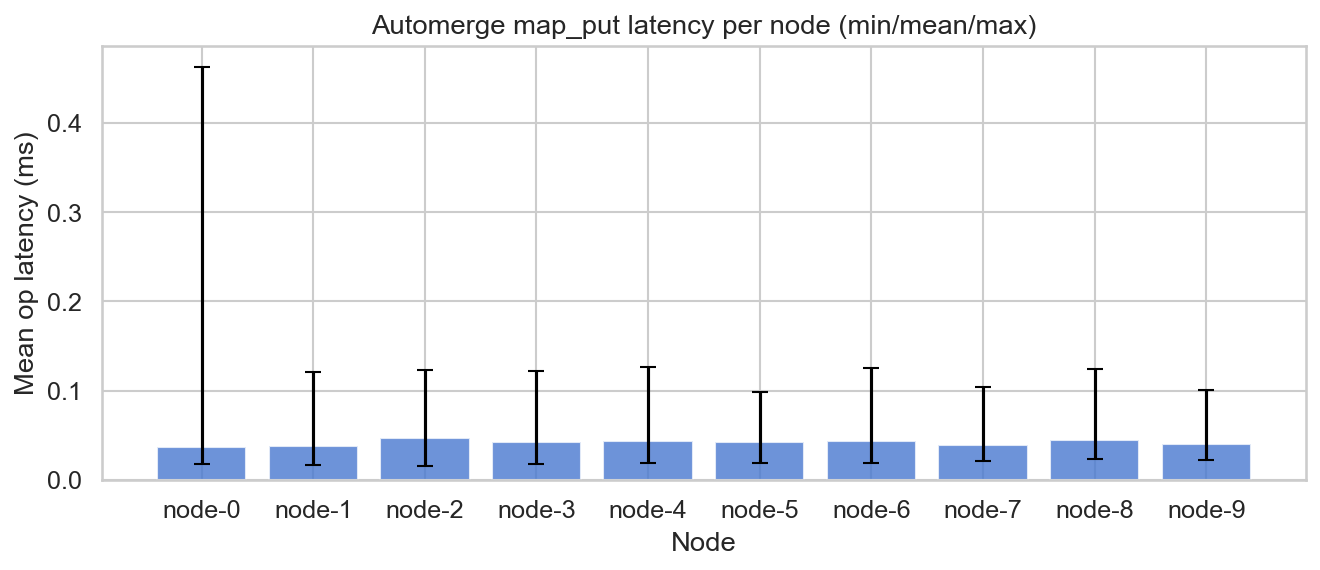

 actor  count      min  mean_ms      max
node-0    260 0.017625 0.036260 0.462750
node-1    260 0.016709 0.037729 0.121042
node-2    240 0.015875 0.047255 0.123458
node-3    200 0.017625 0.042949 0.121958
node-4    160 0.018958 0.044072 0.125834
node-5    120 0.018625 0.042462 0.098250
node-6     80 0.018709 0.044073 0.125500
node-7     80 0.021000 0.038617 0.103750
node-8     40 0.023625 0.044956 0.123875
node-9     40 0.022208 0.039817 0.100542


In [13]:
if metrics:
    op_df = metrics["replicant.op.duration"].copy()
    op_df["mean_ms"] = op_df["sum"] / op_df["count"]
    op_df = op_df.sort_values("actor", key=lambda s: s.map(lambda v: int(v.split("-")[1])))

    fig, ax = plt.subplots(figsize=(max(4, len(op_df) * 0.9), 4))
    bars = ax.bar(op_df["actor"], op_df["mean_ms"], alpha=0.8)
    if "min" in op_df.columns and "max" in op_df.columns:
        ax.errorbar(
            op_df["actor"],
            op_df["mean_ms"],
            yerr=[op_df["mean_ms"] - op_df["min"], op_df["max"] - op_df["mean_ms"]],
            fmt="none",
            color="black",
            capsize=4,
        )
    ax.set_xlabel("Node")
    ax.set_ylabel("Mean op latency (ms)")
    ax.set_title("Automerge map_put latency per node (min/mean/max)")
    fig.tight_layout()
    fig.savefig(FIGS / "op_latency.pdf")
    plt.show()
    print(op_df[["actor", "count", "min", "mean_ms", "max"]].to_string(index=False))


### Document size after convergence

Serialized Automerge document size (bytes) per node after all ops are applied.
All nodes should hold the same logical state — size differences reveal any causal history divergence.


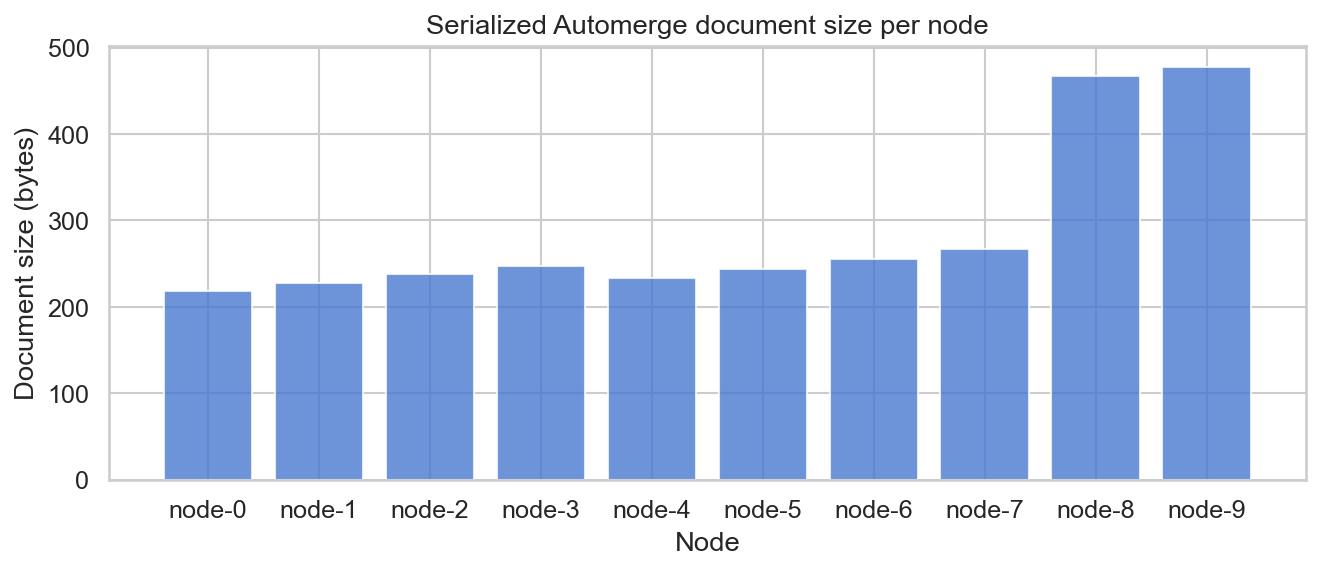

 actor  bytes
node-0    218
node-1    228
node-2    238
node-3    247
node-4    233
node-5    244
node-6    256
node-7    267
node-8    467
node-9    478


In [14]:
if metrics:
    doc_df = metrics["replicant.doc.size_bytes"].copy()
    doc_df = doc_df.sort_values("actor", key=lambda s: s.map(lambda v: int(v.split("-")[1])))

    fig, ax = plt.subplots(figsize=(max(4, len(doc_df) * 0.9), 4))
    ax.bar(doc_df["actor"], doc_df["value"], alpha=0.8)
    ax.set_xlabel("Node")
    ax.set_ylabel("Document size (bytes)")
    ax.set_title("Serialized Automerge document size per node")
    fig.tight_layout()
    fig.savefig(FIGS / "doc_size.pdf")
    plt.show()
    print(doc_df[["actor", "value"]].rename(columns={"value": "bytes"}).to_string(index=False))
